# 05 練習問題 解答 — consumption vs recycling
対象: [`notebooks/05_consumption_vs_recycling.ipynb`](../notebooks/05_consumption_vs_recycling.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M, S = (Species(x) for x in ['m','s'])
B_M, B_S = 1.0, 1.0
def R(a,b,k): return ReactionRule(a,b,k)
def build(a_s, k_pair, phi, a_m=10.0):
    mdl = NetworkModel()
    for r in [R([],[M],a_m), R([],[S],a_s), R([M],[],B_M), R([S],[],B_S)]:
        mdl.add_reaction_rule(r)
    if (1-phi)>0: mdl.add_reaction_rule(R([M,S],[],k_pair*(1-phi)))
    if phi>0:     mdl.add_reaction_rule(R([M,S],[S],k_pair*phi))
    return mdl
def m_of(a_s, k_pair, phi, a_m=10.0):
    return run_simulation(200.0, y0={}, model=build(a_s,k_pair,phi,a_m), solver='ode', ndiv=1, species_list=['m','s']).as_array()[-1][1]

## Q1. $k_{pair}$ を 5→100 に上げ、$\varphi{=}0$ で鋭い linear-to-zero 閾値が戻るか

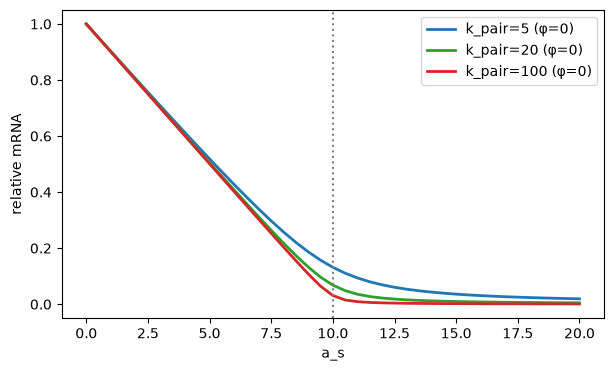

In [2]:
a_grid = np.linspace(0,20,41)
fig, ax = plt.subplots(figsize=(7,4))
for kp, c in [(5.0,'C0'),(20.0,'C2'),(100.0,'C3')]:
    y = [m_of(a, kp, 0.0)/10 for a in a_grid]
    ax.plot(a_grid, y, color=c, lw=2, label=f'k_pair={kp:.0f} (φ=0)')
ax.axvline(10, ls=':', c='gray'); ax.set_xlabel('a_s'); ax.set_ylabel('relative mRNA'); ax.legend(); plt.show()

**答**: 消費型（φ=0）でも $k_{pair}$ を上げると、なだらかな曲線（k=5）から **04 のような鋭い linear-to-zero 閾値**（k=100, a_s=10 で折れて底打ち）へ戻る。つまり鋭い閾値は **「sRNA が消費される（φ=0）」＋「ペアリングが強い（$k_{pair}$ 大）」の両方**が必要、という 05 の結論を再確認。

## Q2. 閾値位置は $\varphi{=}0$ で本当に $a_s{=}a_m$ か（$a_m$ を変えて追随を見る）

  a_m  threshold a_s (m→~0)
    6                   6.0
   10                  10.0
   18                  17.5


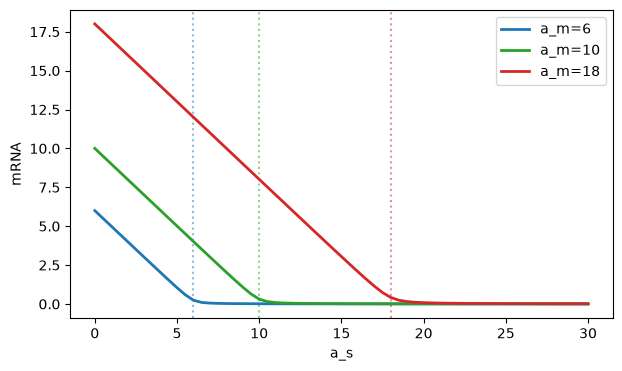

In [3]:
print(f"{'a_m':>5}{'threshold a_s (m→~0)':>22}")
a_grid = np.linspace(0,30,61)
fig, ax = plt.subplots(figsize=(7,4))
for a_m, c in [(6.0,'C0'),(10.0,'C2'),(18.0,'C3')]:
    y = np.array([m_of(a,100.0,0.0,a_m) for a in a_grid])
    ax.plot(a_grid, y, color=c, lw=2, label=f'a_m={a_m:.0f}')
    # 折れ点 = m が a_m の 5% を切る a_s
    thr = a_grid[np.where(y < 0.05*a_m)[0][0]]
    ax.axvline(a_m, ls=':', c=c, alpha=.5); print(f'{a_m:5.0f}{thr:22.1f}')
ax.set_xlabel('a_s'); ax.set_ylabel('mRNA'); ax.legend(); plt.show()

**答**: 折れ点（mRNA が底打ちする $a_s$）は **$a_m$ に一致して動く**（a_m=6→閾値≈6、a_m=18→≈18）。消費型の閾値は「sRNA 転写が mRNA 転写に追いつく点 $a_s=a_m$」で決まる滴定的スイッチ、というのが確かめられる。

## Q3.（考察）$\varphi$ を系統の形質として解釈

**答（考察）**: $\varphi$（sRNA が再利用される確率）は「sRNA-mRNA 対合の後、sRNA が共分解されるか（φ→0, 化学量論）／触媒的に外れて次へ回るか（φ→1）」を表す。これは Hfq・RNase E との連携や、対合後に sRNA が保護されるかに依存し得る。
オーソログ間で **rim / C 末端テール（RNA 交換・解離を担う）** の保存が違えば、対合後に sRNA が外れやすい（φ 大＝触媒寄り）か、共分解されやすい（φ 小＝スイッチ寄り）かが変わると予測できる。すなわち φ は「系統ごとの制御のデジタル/アナログ度」を測る形質になりうる。定量的な検証は **bio-e**（代表オーソログ）で行う。